Attempting to load CelebA dataset...
CelebA download failed (Failed to retrieve file url:

	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=0B7EVK8r0v71pZjFTYXZWM3FlRnM

but Gdown can't. Please check connections and permissions.). Falling back to synthetic face-like images for local execution...
Epoch [1/5], Loss: 4516.2423


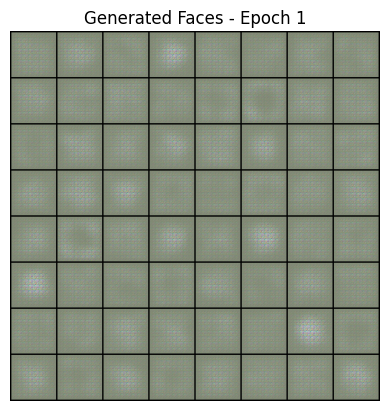

Epoch [2/5], Loss: 1592.4555


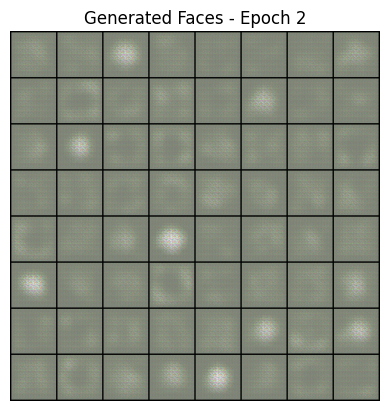

Epoch [3/5], Loss: 1734.8961


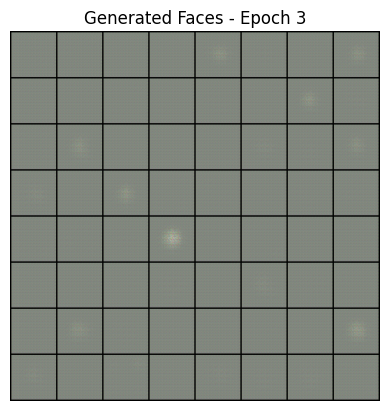

Epoch [4/5], Loss: 1227.8439


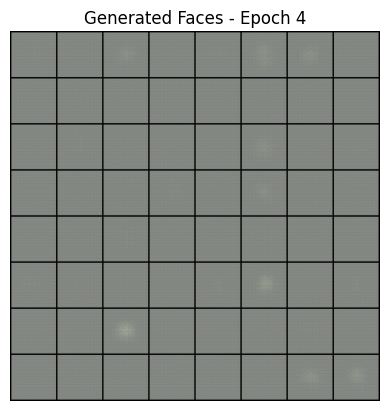

Epoch [5/5], Loss: 1723.0541


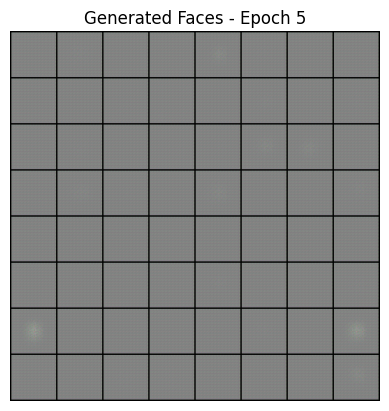

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, TensorDataset
import matplotlib.pyplot as plt
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
image_size = 64
batch_size = 128
latent_dim = 100
num_epochs = 5
learning_rate = 1e-3

transform = transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

try:
    print("Attempting to load CelebA dataset...")
    dataset = datasets.CelebA(root='data', split='train', download=True, transform=transform)
    dataset = Subset(dataset, range(500))
except Exception as e:
    print(f"CelebA download failed ({e}). Falling back to synthetic face-like images for local execution...")
    # Generate 500 synthetic 3-channel images (e.g. gradients and random structures)
    synthetic_data = []
    for _ in range(500):
        img = torch.randn(3, image_size, image_size) * 0.2
        # Create a face-like central blob
        y, x = torch.meshgrid(torch.linspace(-1, 1, image_size), torch.linspace(-1, 1, image_size), indexing='ij')
        mask = (x**2 + y**2) < 0.5
        img[:, mask] += 0.5
        synthetic_data.append(img)
    synthetic_tensor = torch.stack(synthetic_data)
    dataset = TensorDataset(synthetic_tensor, torch.zeros(500))

daterviewer_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512), nn.ReLU()
        )
        self.fc_mu = nn.Linear(512*4*4, latent_dim)
        self.fc_logvar = nn.Linear(512*4*4, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc_mu(x), self.fc_logvar(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(latent_dim, 512*4*4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(x.size(0), 512, 4, 4)
        return self.deconv(x)

class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

def vae_loss(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div

model = VAE(latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in daterviewer_dataloader:
        images = batch[0].to(device)
        recon, mu, logvar = model(images)
        loss = vae_loss(recon, images, mu, logvar)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(daterviewer_dataloader.dataset):.4f}")

    model.eval()
    with torch.no_grad():
        z = torch.randn(64, latent_dim).to(device)
        sample_images = model.decoder(z).cpu() * 0.5 + 0.5
        grid = torchvision.utils.make_grid(sample_images, nrow=8)
        plt.imshow(grid.permute(1, 2, 0))
        plt.axis('off')
        plt.title(f"Generated Faces - Epoch {epoch+1}")
        plt.show()